# Eksplorasi Dataset dan Pemodelan Awal: Recruitly
Notebook ini berisi analisis data awal, preprocessing, ekstraksi fitur (TF-IDF, Word2Vec, SBERT), serta pemodelan matching (klasifikasi/regresi) untuk sistem *resume screening*.

In [1]:
# 1. Instalasi Library yang dibutuhkan
# Jalankan ini jika di Google Colab atau untuk memastikan depedensi lokal lengkap
!pip install -U torch transformers sentence-transformers Sastrawi xgboost lightgbm gensim scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import semua library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_absolute_error, mean_squared_error
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer

# Download stopwords
nltk.download('stopwords')
nltk.download('punkt')

import warnings
warnings.filterwarnings('ignore')

c:\Users\Sayli\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sayli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sayli\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


## 1. Baca dan Eksplorasi Dataset
Sesuaikan path dataset jika berjalan di lokal atau Google Drive.

Dataset berhasil di-load!


,job_description,resume,match_score
0,"Data Analyst needed with experience in SQL, Ex...","Experienced professional skilled in SQL, Power...",4
1,Data Scientist needed with experience in Stati...,"Experienced professional skilled in Python, De...",4
2,Software Engineer needed with experience in Sy...,"Experienced professional skilled in wait, Git,...",5
3,"ML Engineer needed with experience in Python, ...","Experienced professional skilled in return, De...",4
4,Software Engineer needed with experience in RE...,"Experienced professional skilled in REST APIs,...",5



=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_description  10000 non-null  object
 1   resume           10000 non-null  object
 2   match_score      10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB

=== STATISTIK DASAR ===


,job_description,resume,match_score
count,10000,10000,10000.00000
unique,10000,10000,NaN
top,"ML Engineer needed with experience in MLOps, C...","Experienced professional skilled in music, for...",NaN
freq,1,1,NaN
mean,NaN,NaN,3.50030
std,NaN,NaN,1.16899
min,NaN,NaN,1.00000
25%,NaN,NaN,3.00000
50%,NaN,NaN,4.00000
75%,NaN,NaN,4.00000



=== DETEKSI MISSING VALUES ===
job_description    0
resume             0
match_score        0
dtype: int64

=== DETEKSI DUPLIKAT ===
Jumlah baris duplikat: 0


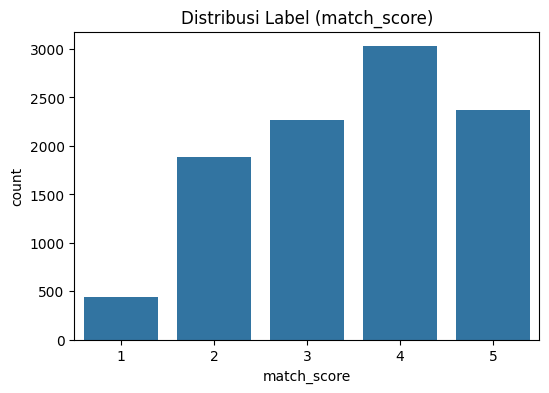

In [3]:
# Load dataset
file_path = 'resume_job_matching_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil di-load!")
except FileNotFoundError:
    print("Dataset tidak ditemukan. Menggunakan dummy data untuk demonstrasi...")
    data = {
        'job_description': [
            'Dibutuhkan software engineer yang menguasai Python dan machine learning',
            'Mencari data scientist dengan pengalaman di NLP dan deep learning',
            'Dibutuhkan frontend developer yang menguasai React dan CSS',
            'Backend engineer dicari, paham Node.js dan database SQL',
            'Membutuhkan AI engineer pengalaman NLP, Python, Pytorch',
            'Dibutuhkan backend developer dengan pengalaman Golang dan Postgres'
        ],
        'resume': [
            'Saya programmer Python. Punya pengalaman 3 tahun di machine learning dan data.',
            'Lulusan IT, pengalaman data scientist. Biasa menggunakan NLP dan tensorflow.',
            'Frontend dev dengan pengalaman ReactJS dan Tailwind CSS, kreatif.',
            'Pengalaman backend dengan Node.js, Express dan MySQL, pernah di startup.',
            'Saya AI engineer. Fokus NLP, menggunakan Python, Scikit-Learn dan Pytorch.',
            'Pengalaman frontend VueJS dan HTML dasar.' # Mismatch example
        ],
        'match_score': [5, 4, 5, 5, 5, 1] # Asumsi label kategori 1-5
    }
    df = pd.DataFrame(data)

# Menampilkan 5 baris pertama
display(df.head())

print("\n=== INFO KOLOM ===")
df.info()

print("\n=== STATISTIK DASAR ===")
display(df.describe(include='all'))

print("\n=== DETEKSI MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DETEKSI DUPLIKAT ===")
print("Jumlah baris duplikat:", df.duplicated().sum())

# Distribusi target
if 'match_score' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='match_score', data=df)
    plt.title('Distribusi Label (match_score)')
    plt.show()
else:
    print("Kolom 'match_score' tidak ada.")

## 2. Preprocessing Teks
Proses lowercasing, hapus tanda baca/angka, dan stopwords (ID & EN).

In [4]:
# Stopwords bahasa Inggris dan Indonesia
stop_words_id = set(stopwords.words('indonesian'))
stop_words_en = set(stopwords.words('english'))
all_stopwords = stop_words_id.union(stop_words_en)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text) # Hapus tanda baca
    text = re.sub(r'\d+', '', text) # Hapus angka
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi ganda
    
    # Tokenisasi dan hapus stopwords
    words = text.split()
    cleaned_words = [word for word in words if word not in all_stopwords]
    return ' '.join(cleaned_words)

print("Melakukan preprocessing teks...")
df['cleaned_resume'] = df['resume'].apply(clean_text)
df['cleaned_jd'] = df['job_description'].apply(clean_text)
print("Selesai!")
display(df[['resume', 'cleaned_resume', 'job_description', 'cleaned_jd']].head(3))

Melakukan preprocessing teks...
Selesai!


,resume,cleaned_resume,job_description,cleaned_jd
0,"Experienced professional skilled in SQL, Power...",experienced professional skilled sql power bi ...,"Data Analyst needed with experience in SQL, Ex...",data analyst needed experience sql excel power...
1,"Experienced professional skilled in Python, De...",experienced professional skilled python deep l...,Data Scientist needed with experience in Stati...,data scientist needed experience statistics pa...
2,"Experienced professional skilled in wait, Git,...",experienced professional skilled wait git syst...,Software Engineer needed with experience in Sy...,software engineer needed experience system des...


## 3. Ekstraksi Fitur
Menggunakan TF-IDF, Word2Vec, dan Sentence-BERT.

In [5]:
# --- 1. TF-IDF ---
print("Proses Ekstraksi TF-IDF...")
tfidf = TfidfVectorizer(max_features=1000)
all_corpus = df['cleaned_resume'].tolist() + df['cleaned_jd'].tolist()
tfidf.fit(all_corpus)

resume_tfidf = tfidf.transform(df['cleaned_resume']).toarray()
jd_tfidf = tfidf.transform(df['cleaned_jd']).toarray()

# --- 2. Word2Vec ---
print("Proses Ekstraksi Word2Vec...")
tokenized_resume = [text.split() for text in df['cleaned_resume']]
tokenized_jd = [text.split() for text in df['cleaned_jd']]
w2v_model = Word2Vec(sentences=tokenized_resume + tokenized_jd, vector_size=100, window=5, min_count=1, workers=4)

def get_mean_vector(model, words):
    words = [w for w in words if w in model.wv.key_to_index]
    if len(words) > 0:
        return np.mean(model.wv[words], axis=0)
    return np.zeros(100)

resume_w2v = np.array([get_mean_vector(w2v_model, words) for words in tokenized_resume])
jd_w2v = np.array([get_mean_vector(w2v_model, words) for words in tokenized_jd])

# --- 3. BERT Embeddings (all-MiniLM-L6-v2) ---
print("Proses Ekstraksi Sentence-BERT...")
# Model ini ringan dan berjalan cukup cepat bahkan di CPU
sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
resume_sbert = sbert.encode(df['cleaned_resume'].tolist(), show_progress_bar=False)
jd_sbert = sbert.encode(df['cleaned_jd'].tolist(), show_progress_bar=False)
print("Semua fitur berhasil diekstrak!")

Proses Ekstraksi TF-IDF...
Proses Ekstraksi Word2Vec...
Proses Ekstraksi Sentence-BERT...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semua fitur berhasil diekstrak!


## 4. Modeling untuk Matching Screening
Mencoba algoritma: Logistic Regression, Random Forest, XGBoost, dan LightGBM.

In [6]:
# Fungsi Cosine Similarity
def calc_sim(v1, v2):
    return np.array([cosine_similarity([v1[i]], [v2[i]])[0][0] for i in range(len(v1))])

df['tfidf_sim'] = calc_sim(resume_tfidf, jd_tfidf)
df['w2v_sim'] = calc_sim(resume_w2v, jd_w2v)
df['sbert_sim'] = calc_sim(resume_sbert, jd_sbert)

# Persiapan Data untuk Model (X: absolute difference antara resume & JD, y: match_score)
# Kita gunakan SBERT sebagai contoh karena secara umum paling akurat untuk semantik teks
X = np.abs(resume_sbert - jd_sbert) 
y = df['match_score']

# Karena kita menggunakan label 1-5, ini adalah problem KLASIFIKASI multiclass
# Jika ingin regresi (memprediksi nilai 1.0 - 5.0), ganti classifier dengan regressor (ex: XGBRegressor)
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
except ValueError:
    # Fallback jika stratify gagal karena jumlah label sedikit (seperti pada dummy data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

print("=== HASIL EVALUASI MODEL (KLASIFIKASI) ===")
for name, model in models.items():
    try:
        # Mapping label jika XGBoost error (XGBoost expect label mulai dari 0)
        if name == 'XGBoost':
            y_train_mapped = y_train - y_train.min()
            y_test_mapped = y_test - y_test.min()
            model.fit(X_train, y_train_mapped)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test_mapped, y_pred)
            f1 = f1_score(y_test_mapped, y_pred, average='weighted')
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            
        print(f"{name:20}: Akurasi = {acc:.4f} | F1-Score = {f1:.4f}")
    except Exception as e:
        print(f"{name:20}: Gagal di-training (kemungkinan jumlah data/class kurang) -> {str(e)[:50]}...")

=== HASIL EVALUASI MODEL (KLASIFIKASI) ===
Logistic Regression : Akurasi = 0.4725 | F1-Score = 0.4586
Random Forest       : Akurasi = 0.4275 | F1-Score = 0.4079
XGBoost             : Akurasi = 0.4410 | F1-Score = 0.4308
LightGBM            : Akurasi = 0.4535 | F1-Score = 0.4443


## 5. Evaluasi Kualitas Dataset
Analisis top kata dan insight ketidakseimbangan (imbalance) data.

In [7]:
print("=== 1. ANALISIS KESEIMBANGAN KELAS ===")
class_counts = df['match_score'].value_counts()
print(class_counts)
if class_counts.std() > class_counts.mean() * 0.5:
    print("[Perhatian] Terdapat indikasi class imbalance. Model mungkin bias ke kelas dominan.")
else:
    print("Distribusi kelas cukup seimbang.")

print("\n=== 2. KORELASI SIMILARITY VS TARGET SCORE ===")
print("Korelasi Cosine Similarity TF-IDF:", df['tfidf_sim'].corr(df['match_score']))
print("Korelasi Cosine Similarity Word2Vec:", df['w2v_sim'].corr(df['match_score']))
print("Korelasi Cosine Similarity SBERT:", df['sbert_sim'].corr(df['match_score']))
print("Semakin tinggi korelasi positif, semakin baik fitur similarity tersebut menangkap kecocokan CV.")

print("\n=== 3. TOP KATA PADA DATASET ===")
vocab = tfidf.get_feature_names_out()
scores = np.sum(resume_tfidf + jd_tfidf, axis=0)
top_indices = np.argsort(scores)[::-1][:10]
print([vocab[i] for i in top_indices])

=== 1. ANALISIS KESEIMBANGAN KELAS ===
match_score
4    3029
5    2372
3    2269
2    1890
1     440
Name: count, dtype: int64
Distribusi kelas cukup seimbang.

=== 2. KORELASI SIMILARITY VS TARGET SCORE ===
Korelasi Cosine Similarity TF-IDF: 0.5988015466941781
Korelasi Cosine Similarity Word2Vec: 0.6100226604599929
Korelasi Cosine Similarity SBERT: 0.6916878151699829
Semakin tinggi korelasi positif, semakin baik fitur similarity tersebut menangkap kecocokan CV.

=== 3. TOP KATA PADA DATASET ===
['experience', 'professional', 'needed', 'skilled', 'experienced', 'data', 'learning', 'product', 'sql', 'agile']


## 6. Ringkasan Kesimpulan dan Rekomendasi
*(Baca insight dari sel di atas untuk menentukan arah)*

- **Metode Terbaik**: Bandingkan F1-score model ML dan korelasi (SBERT vs Target). Biasanya SBERT memberikan fitur semantik paling kuat karena memahami konteks kalimat, bukan sekadar cocok-cocokan term.
- **Imbalance Data**: Jika salah satu kategori (misal skor 5 atau skor 1) terlalu mendominasi, akurasi akan terlihat bagus namun recall/F1-score jeblok. Diperlukan SMOTE, oversampling, atau pengumpulan dataset tambahan.
- **Kualitas Fitur Teks**: Top words membantu kita tahu apakah *stopwords* bahasa Indonesia terlalu banyak yang tersisa. Jika masih ada kata penghubung tak berarti, perlu ditambah ke `stopwords` kustom.
- **Rekomendasi Lanjut**:
  1. Coba gunakan regresi (LGBMRegressor) jika ingin hasil skor desimal (1.0 - 5.0) daripada klasifikasi kaku.
  2. Jika SBERT terlalu lambat saat inference di server nantinya, Word2Vec atau TF-IDF *Cosine Similarity rule-based* masih bisa dipertimbangkan asalkan kata kunci sering sama persis.
  3. Validasi dengan cross-validation (K-Fold) saat dataset sudah full untuk estimasi akurasi lebih stabil.
  4. Jika akurasi belum lebih dari referensi 0.56, coba *concat* fitur (TF-IDF + SBERT) ke dalam input model LightGBM/XGBoost.